#### EDA 탐색적 데이터 분석
#### 농구선수의 게임 데이터를 활용한 포지션 예측을 위한 EDA

##### 문제 정의
NBA 농구 선수들의 게임 기록을 데이터로 사용해서 특정 농구 선수의 포지션을 예측

In [1]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("../Data/basketball.csv")
df.head()

,Player,Pos,3P,2P,TRB,AST,STL,BLK
0,Alex Abrines,SG,1.4,0.6,1.3,0.6,0.5,0.1
1,Steven Adams,C,0.0,4.7,7.7,1.1,1.1,1.0
2,Alexis Ajinca,C,0.0,2.3,4.5,0.3,0.5,0.6
3,Chris Andersen,C,0.0,0.8,2.6,0.4,0.4,0.6
4,Will Barton,SG,1.5,3.5,4.3,3.4,0.8,0.5


- Player : 선수이름
- Pos : 포지션(SG: Shooting Guard, C: Center)
- 3p : 한 경기당 평균 3점슛 성공 횟수
- 2p : 한 경기당 평균 2점슛 성공 횟수
- TRB : 한 경기당 평균 리바운드 성공 횟수
- AST : 한 경기당 평균 어시스트 성공 횟수
- STL : 한 경기당 평균 스틸 성공 횟수
- BLK : 한 경기당 평균 블로킹 성공 횟수

In [3]:
# 포지션의 종류 파악
# 포지션의 갯수 파악



#### 포지션별 내용
- C : Center 는 골대, 포스트 근처에서 슛을 블로킹하고, 리바운드 하며 바깥으로 쳐내며 골대 근처에서 2점 슛으로 득점하기도 한다.
- SG : Shooting Guard는 3점슛 등 장거리에서 슛을 해서 점수를 얻는 역할

### 데이터 시각화

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib

#### 스틸, 2점슛, 데이터 시각화

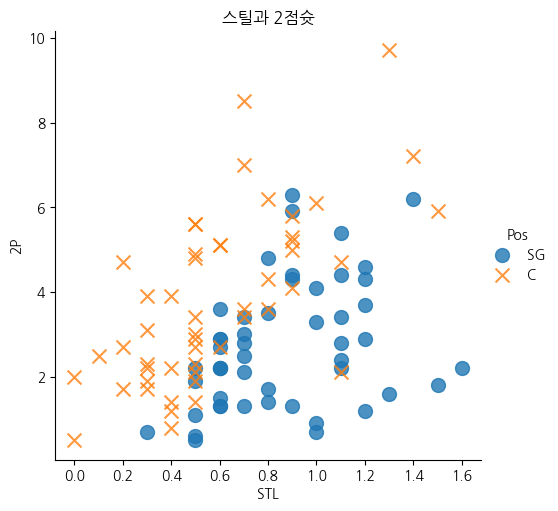

In [5]:
sns.lmplot(
  x='STL',
  y='2P',
  data = df,
  fit_reg=False,
  scatter_kws={'s' : 100},
  markers=['o','x'],
  hue='Pos'
)

plt.title('스틸과 2점슛')

plt.show()



> STL과 SP는 Feature로는 부적합 할 것 같다

#### 어시스트와 2점슛 데이터 시각화

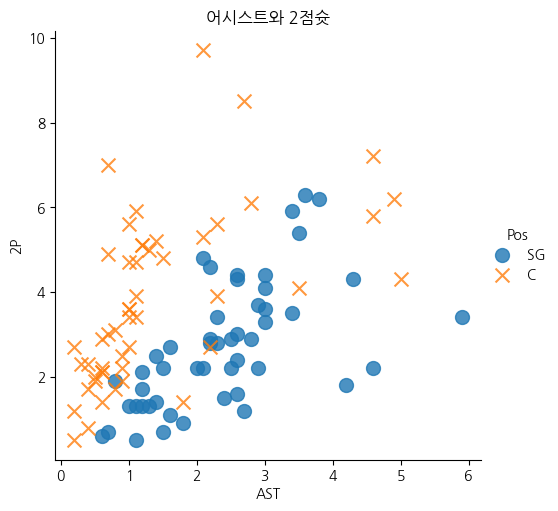

In [6]:
sns.lmplot(
  x='AST',
  y='2P',
  data = df,
  fit_reg=False,
  scatter_kws={'s' : 100},
  markers=['o','x'],
  hue='Pos'
)

plt.title('어시스트와 2점슛')

plt.show()

> 2점슛, 어시스트, 스틸의 속성으로 데이터를 분포시킬 경우   
슈팅가드와 센터의 경계가 너무 근접해서 분류하기에 모호하다

#### 블로킹과 3점슛 데이터 시각화

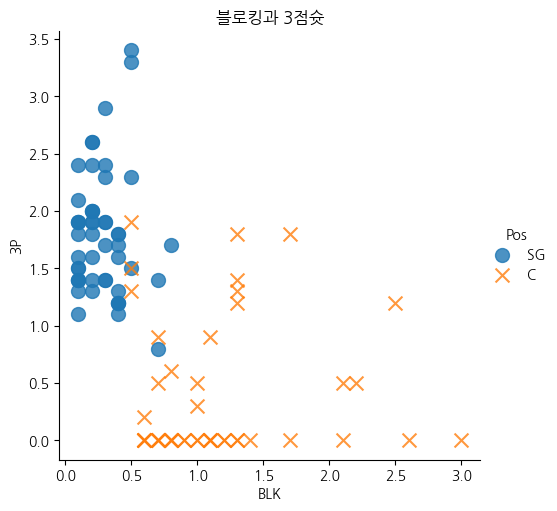

In [7]:
sns.lmplot(
  x='BLK',
  y='3P',
  data = df,
  fit_reg=False,
  scatter_kws={'s' : 100},
  markers=['o','x'],
  hue='Pos'
)

plt.title('블로킹과 3점슛')

plt.show()

In [8]:
# 분별력이 없는 특징(feature)을 데이터에서 제거

df.drop(
  ['2P','AST','STL'],
  axis='columns',
  inplace=True
)
df.head()

,Player,Pos,3P,TRB,BLK
0,Alex Abrines,SG,1.4,1.3,0.1
1,Steven Adams,C,0.0,7.7,1.0
2,Alexis Ajinca,C,0.0,4.5,0.6
3,Chris Andersen,C,0.0,2.6,0.6
4,Will Barton,SG,1.5,4.3,0.5


In [9]:
# Train과 Test로 나누어서 저장
# Test_size = 0.2
# train : basketball_train.csv
# test : basketball_test.csv


from sklearn.model_selection import train_test_split
train, test = \
  train_test_split(
    df,
    test_size=0.2
  )

In [10]:
train.shape

(80, 5)

In [11]:
test.shape

(20, 5)

In [12]:
train.to_csv("../Data/basketball_train.csv", index=None)
test.to_csv("../Data/basketball_test.csv", index=None)